In [1]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score



In [2]:
# Load dataset


df = pd.read_csv("../brca.csv")

df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [3]:
# dataset shape
df.shape

(569, 32)

In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
# dataset info
df

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,20.920,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.147400,0.2149,0.06879,...,29.41,179.10,1819.0,0.14070,0.41860,0.65990,0.25420,0.2929,0.09873,M
565,21.560,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.138900,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.41070,0.22160,0.2060,0.07115,M
566,20.130,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.097910,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.32150,0.16280,0.2572,0.06637,M
567,16.600,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.053020,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.34030,0.14180,0.2218,0.07820,M


In [6]:
# check for missing values  
df.isnull().sum()

x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

In [5]:
#print the column names
print(df.columns)

Index(['x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean',
       'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean',
       'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean',
       'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se',
       'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')


In [7]:
#count of target variable
df['y'].value_counts()

y
B    357
M    212
Name: count, dtype: int64

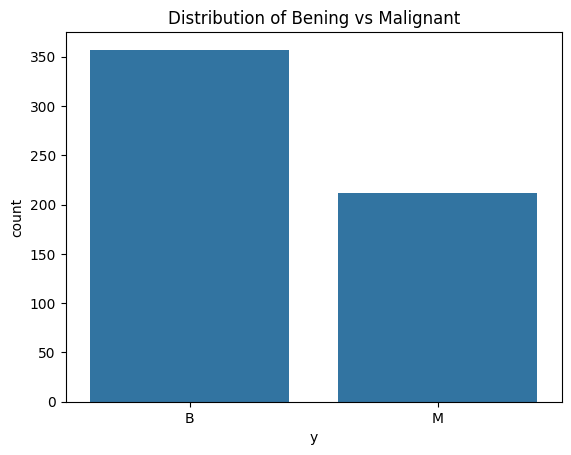

In [8]:
# visualize the distribution of the target variable
sns.countplot(x='y', data=df)
plt.title("Distribution of Bening vs Malignant")
plt.show()

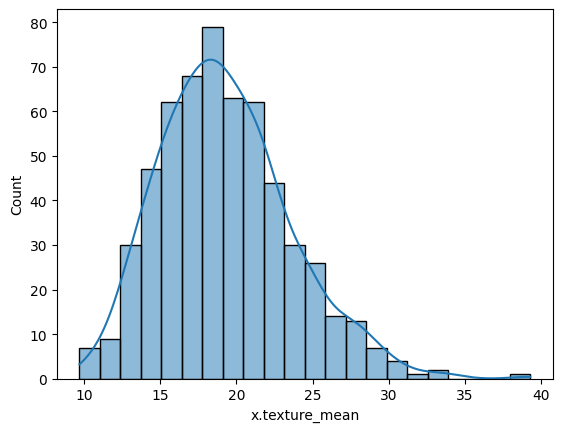

In [9]:
# Feature Distribution Analysis
sns.histplot(df["x.texture_mean"], kde=True)
plt.show()

In [10]:
# Encode target variable M=1, B=0
df["y"] = df["y"].map({"M":1, "B":0})

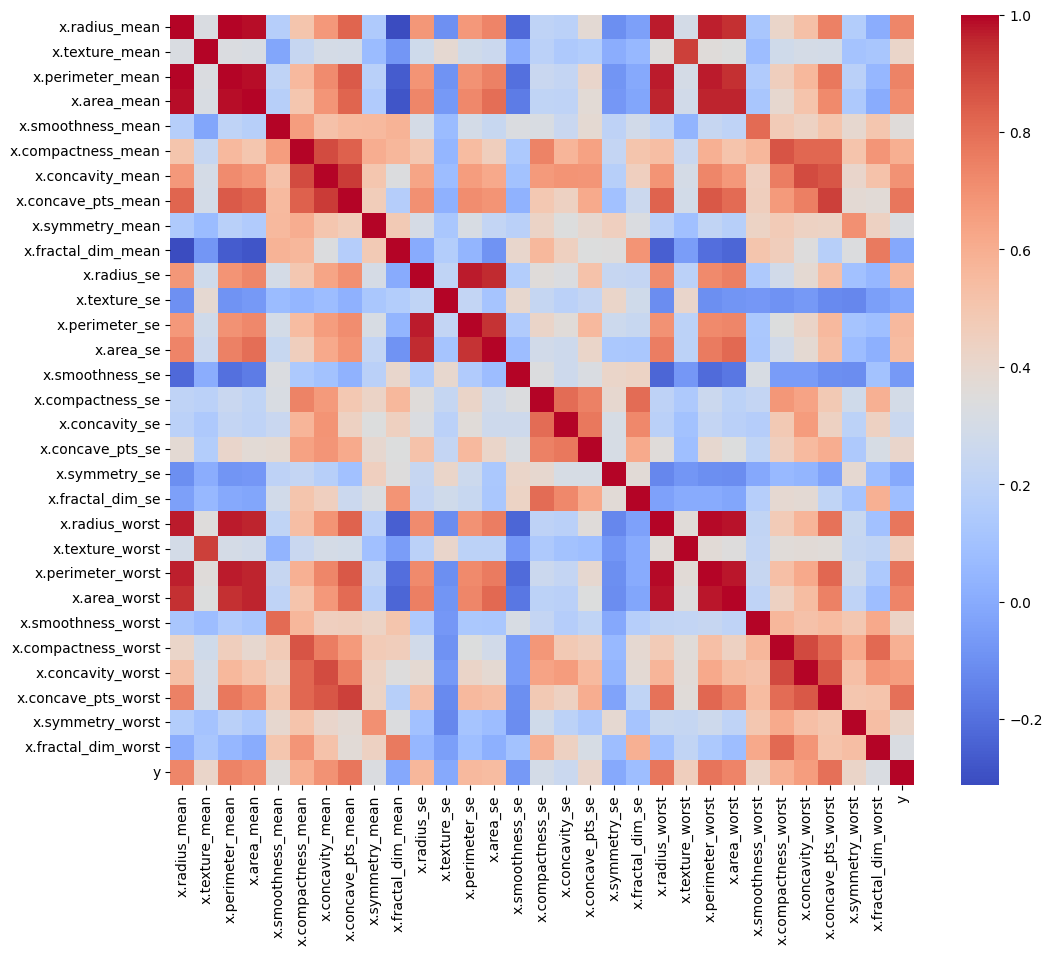

In [17]:
#correlation matix and heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [11]:
#define features and target variable
X = df.filter(like='x.')
y = df['y']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scaling data
scaler = StandardScaler()
#Adaptation and transformation in training data
X_train_scaled = scaler.fit_transform(X_train)
#transformation in test data
X_test_scaled = scaler.transform(X_test)

print("Training will be done with", X_train_scaled.shape[0], "samples.")
print("Testing will be done ", X_test_scaled.shape[0], "samples.")


Training will be done with 455 samples.
Testing will be done  114 samples.


In [13]:
#feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
import joblib

# Αποθήκευση του scaler στον κεντρικό φάκελο
joblib.dump(scaler, 'scaler.pkl')
print("Ο Scaler αποθηκεύτηκε!")

Ο Scaler αποθηκεύτηκε!


In [17]:
#logistic regression model 
log_model=LogisticRegression()
log_model.fit(X_train,y_train)
pred = log_model.predict(X_test)

In [19]:
#accuracy score
acc = accuracy_score(y_test, pred)
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 96.49%


In [20]:
#confusion matrix
confusion_matrix(y_test, pred)

array([[69,  2],
       [ 2, 41]])

In [21]:
#classification report
print(classification_report(y_test, pred))  

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [40]:
#Random Forest

# model training 
rf= RandomForestClassifier()
rf.fit(X_train,y_train)
#prediction
rf_pred = rf.predict(X_test)  
#calculate accuracy  
acc =accuracy_score(y_test, rf_pred)
#print accuracy
print(f"Random Forest Accuracy: {acc*100:.2f}%")



Random Forest Accuracy: 96.49%


In [23]:
#decision tree classifier
#model training
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
#prediction
dt_pred=dt.predict(X_test)
#calculate accuracy
dt_acc=accuracy_score(y_test, dt_pred)
#print accuracy
print(f"Decision Tree Accuracy: {dt_acc*100:.2f}%")

Decision Tree Accuracy: 92.98%


In [24]:
#decision tree evaluation

print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

[[67  4]
 [ 4 39]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



In [25]:
#support vector machine

svm=SVC()
#model training
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train,y_train)
#prediction 
svm_pred = svm.predict(X_test)
#calculate accuracy
svm_acc = accuracy_score(y_test, svm_pred)
#print accuracy
print(f"SVM Accuracy: {svm_acc*100:.2f}%")


SVM Accuracy: 97.37%


In [26]:
#svm evaluation
print(confusion_matrix(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

[[69  2]
 [ 1 42]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [27]:
#logistic regression 
lr=LogisticRegression(max_iter=1000)
#model training
lr.fit(X_train,y_train)
#prediction
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, pred)
#print accuracy
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Logistic Regression Accuracy: 96.49%


In [28]:
#k-nearest neighbors
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_accuacy = knn_model.score(X_test_scaled, y_test)
print(f"KNN Accuracy: {knn_accuacy*100:.2f}%")

KNN Accuracy: 92.98%


In [43]:
models=[
    ('Random Forest', rf),
    ('SVM', svm),
    ('KNN', knn_model)
]
print("10-fold Cross-Validation Results:")
for name, model in models:
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=10)
    print(f" {name}:")
    print(f"  Mean Accuracy: {cv_scores.mean()*100:.2f}%")
    print(f"  Standard Deviation: {cv_scores.std()*100:.2f}%")
    print("_" * 30)


10-fold Cross-Validation Results:
 Random Forest:
  Mean Accuracy: 96.26%
  Standard Deviation: 1.99%
______________________________
 SVM:
  Mean Accuracy: 97.15%
  Standard Deviation: 2.41%
______________________________
 KNN:
  Mean Accuracy: 97.36%
  Standard Deviation: 1.33%
______________________________


In [58]:
from sklearn.neural_network import MLPClassifier


#  2 hidden layers with 10 neurons each
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)


mlp.fit(X_train_scaled, y_train)


mlp_acc = mlp.score(X_test_scaled, y_test)
print(f"Neural Network Accuracy: {mlp_acc*100:.2f}%")

Neural Network Accuracy: 96.49%


In [59]:
#model comparison
print("Model Comparison:")

print(f"Logistic Regression: {lr_acc*100:.2f}%")
print(f"Decision Tree: {dt_acc*100:.2f}%")
print(f"Random Forest: {acc*100:.2f}%")
print(f"SVM: {svm_acc*100:.2f}%")
print(f"KNN: {knn_accuacy*100:.2f}%")
print(f"mpl_acc: {mlp_acc*100:.2f}%")


Model Comparison:
Logistic Regression: 96.49%
Decision Tree: 92.98%
Random Forest: 96.49%
SVM: 97.37%
KNN: 92.98%
mpl_acc: 96.49%


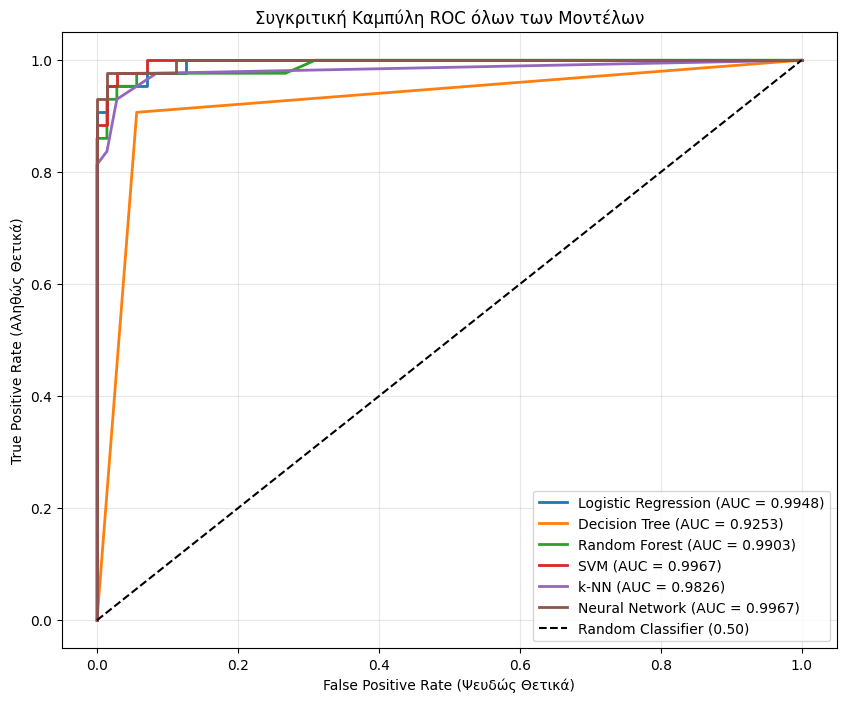

In [66]:
from sklearn.metrics import roc_curve, auc, roc_auc_score


target_label = 'M' if 'M' in y_test.values else 1

plt.figure(figsize=(10, 8))


models_list = [
    (lr, X_test, "Logistic Regression"),
    (dt, X_test, "Decision Tree"),
    (rf, X_test, "Random Forest"),
    (svm, X_test, "SVM"),
    (knn_model, X_test_scaled, "k-NN"),
    (mlp, X_test_scaled, "Neural Network") 
]

for model, data, name in models_list:
   
    probs = model.predict_proba(data)[:, 1]
  
    fpr, tpr, _ = roc_curve(y_test, probs, pos_label=target_label)
    
    auc_score = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})", lw=2)



plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (0.50)")

plt.xlabel("False Positive Rate (Ψευδώς Θετικά)")
plt.ylabel("True Positive Rate (Αληθώς Θετικά)")
plt.title("Συγκριτική Καμπύλη ROC όλων των Μοντέλων")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [32]:
#feature importance from random forest
#importance scores
importances = rf.feature_importances_
#create a dataframe for feature importance
feature_importance=pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances   
})
#sort the dataframe by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

#print top 10 important features
print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
                Feature  Importance
27  x.concave_pts_worst    0.127575
7    x.concave_pts_mean    0.117950
20       x.radius_worst    0.108238
22    x.perimeter_worst    0.097694
23         x.area_worst    0.093413
2      x.perimeter_mean    0.079274
6      x.concavity_mean    0.063853
13            x.area_se    0.041997
3           x.area_mean    0.039205
26    x.concavity_worst    0.034652


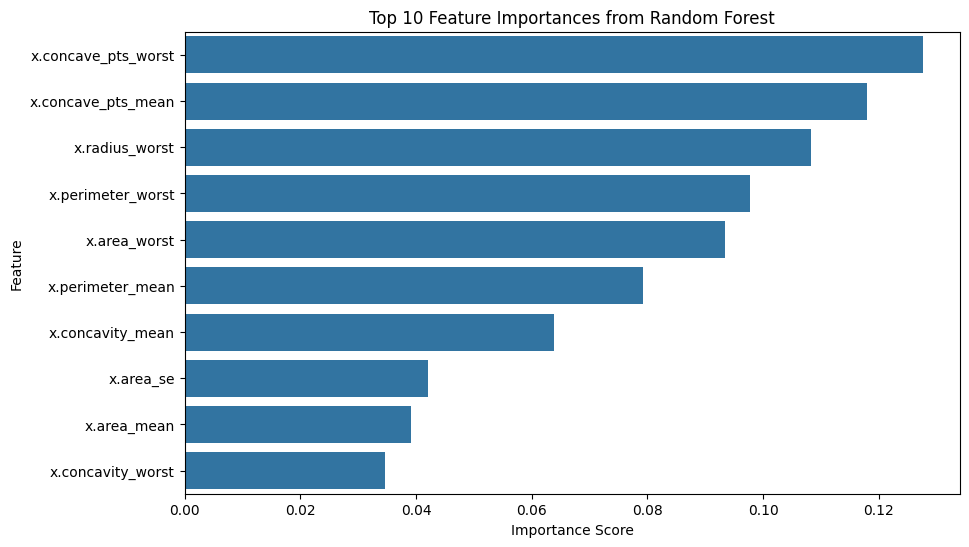

In [33]:
#feature importance visualization
plt.figure(figsize=(10,6))
sns.barplot(
    x=feature_importance['Importance'][:10],
    y=feature_importance['Feature'][:10]
)

plt.title("Top 10 Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [68]:
#save the trained model
import joblib
joblib.dump(mlp, 'neural_network_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Το μοντέλο και ο scaler αποθηκεύτηκαν επιτυχώς!")


Το μοντέλο και ο scaler αποθηκεύτηκαν επιτυχώς!
